In [ ]:
# import yfinance as yf
# import pandas as pd
# df = yf.download("HINDUNILVR.NS", period="5y", progress=True)
# df.columns = df.columns.droplevel(1)
# df.columns = df.columns.get_level_values(0)
# df.columns.name = None
# df = df.reset_index()
# df['Date'] = pd.to_datetime(df['Date'])
# df = df.sort_values('Date')
# df['Return'] = df['Close'].pct_change()

In [1]:
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import torch
import pickle
import matplotlib.pyplot as plt
with open("scalers/HUL.pkl", "rb") as f:
    scaler = pickle.load(f)

model = torch.jit.load('model_path/fin_ohlc_400.pt')
model.eval()

df = yf.download("HINDUNILVR.NS", period="5y", progress=True)
df.columns = df.columns.droplevel(1)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df = df.reset_index()
columns_to_scale = ['Open', 'High', 'Low', 'Close']
df[columns_to_scale] = scaler.transform(df[columns_to_scale])
print("Scaled DataFrame:")
print(df.head())

[*********************100%***********************]  1 of 1 completed

Scaled DataFrame:
        Date     Close      High       Low      Open   Volume
0 2020-12-28  0.341535  0.355316  0.371818  0.367506  1532477
1 2020-12-29  0.337784  0.343503  0.353722  0.359422  1749013
2 2020-12-30  0.355967  0.353060  0.371776  0.355380  1924886
3 2020-12-31  0.346835  0.354988  0.380886  0.360231  1709836
4 2021-01-01  0.340434  0.344323  0.376745  0.359745   830096


[*********************100%***********************]  1 of 1 completed

Scaled DataFrame:
        Date     Close      High       Low      Open   Volume
0 2020-12-28  0.341534  0.355316  0.371818  0.367506  1532477
1 2020-12-29  0.337784  0.343503  0.353723  0.359423  1749013
2 2020-12-30  0.355967  0.353060  0.371776  0.355380  1924886
3 2020-12-31  0.346835  0.354988  0.380886  0.360231  1709836
4 2021-01-01  0.340434  0.344323  0.376745  0.359745   830096

Inverse Transformed DataFrame:
        Date        Close         High          Low         Open   Volume
0 2020-12-28  2196.845215  2223.053968  2185.028420  2211.650951  1532477
1 2020-12-29  2192.615479  2209.812057  2164.935263  2202.455213  1749013
2 2020-12-30  2213.122559  2220.525203  2184.982542  2197.857018  1924886
3 2020-12-31  2202.822998  2222.686567  2195.098401  2203.374851  1709836
4 2021-01-01  2195.603760  2210.731223  2190.499905  2202.822527   830096


In [19]:
import torch
import numpy as np

def test_model(raw_input: np.ndarray, model):
    """
    Returns scaled prediction.
    Shape input: (20, 4)
    Shape output: (k, 4) -> where k is however many days the model predicts
    """
    # Convert to Tensor (1, 20, 4)
    input_tensor = torch.tensor(raw_input).float().unsqueeze(0)
    
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        
    # Return numpy array (N, 4) - Scaled
    return output.cpu().numpy().reshape(-1, 4)


iterations = 1  # How many times to loop
current_input_window = df[columns_to_scale].iloc[-20:].values # Start with last 20 days (scaled)
all_predictions = []

print(f"Starting Autoregression for {iterations} iterations...")

for i in range(iterations):
    # A. Predict
    # (Output shape could be 1x4, 5x4, etc. We don't hardcode it)
    prediction_scaled = test_model(raw_input=current_input_window, model=model)
    
    # B. Store Prediction
    all_predictions.append(prediction_scaled)
    
    # C. Dynamic Window Update
    # k = number of days predicted in this step
    k = prediction_scaled.shape[0] 
    
    # Remove first k rows, append new k rows
    # Logic: New Window = [Old_Window excluding first k] + [New Prediction]
    current_input_window = np.vstack([current_input_window[k:], prediction_scaled])
    
    print(f"Iteration {i+1}: Model predicted {k} days. shifting window by {k}.")

# --- 5. FINALIZE ---
# Stack all predictions into one big array (e.g., if 5 iterations of 1 day -> 5x4)
final_prediction_scaled = np.vstack(all_predictions)

# Inverse Transform to get Real Prices
real_prediction = scaler.inverse_transform(final_prediction_scaled)

print("\n--- Final Accumulated Forecast ---")
print(real_prediction)

Starting Autoregression for 1 iterations...
Iteration 1: Model predicted 5 days. shifting window by 5.

--- Final Accumulated Forecast ---
[[2269.3179 2288.049  2244.3735 2264.048 ]
 [2274.1724 2289.9536 2254.7625 2261.837 ]
 [2273.4204 2284.4907 2240.6904 2258.719 ]
 [2256.4146 2295.0415 2244.1123 2270.2568]
 [2274.8503 2286.383  2255.845  2272.0283]]


Generating chart with detailed annotations...
Chart generated successfully.


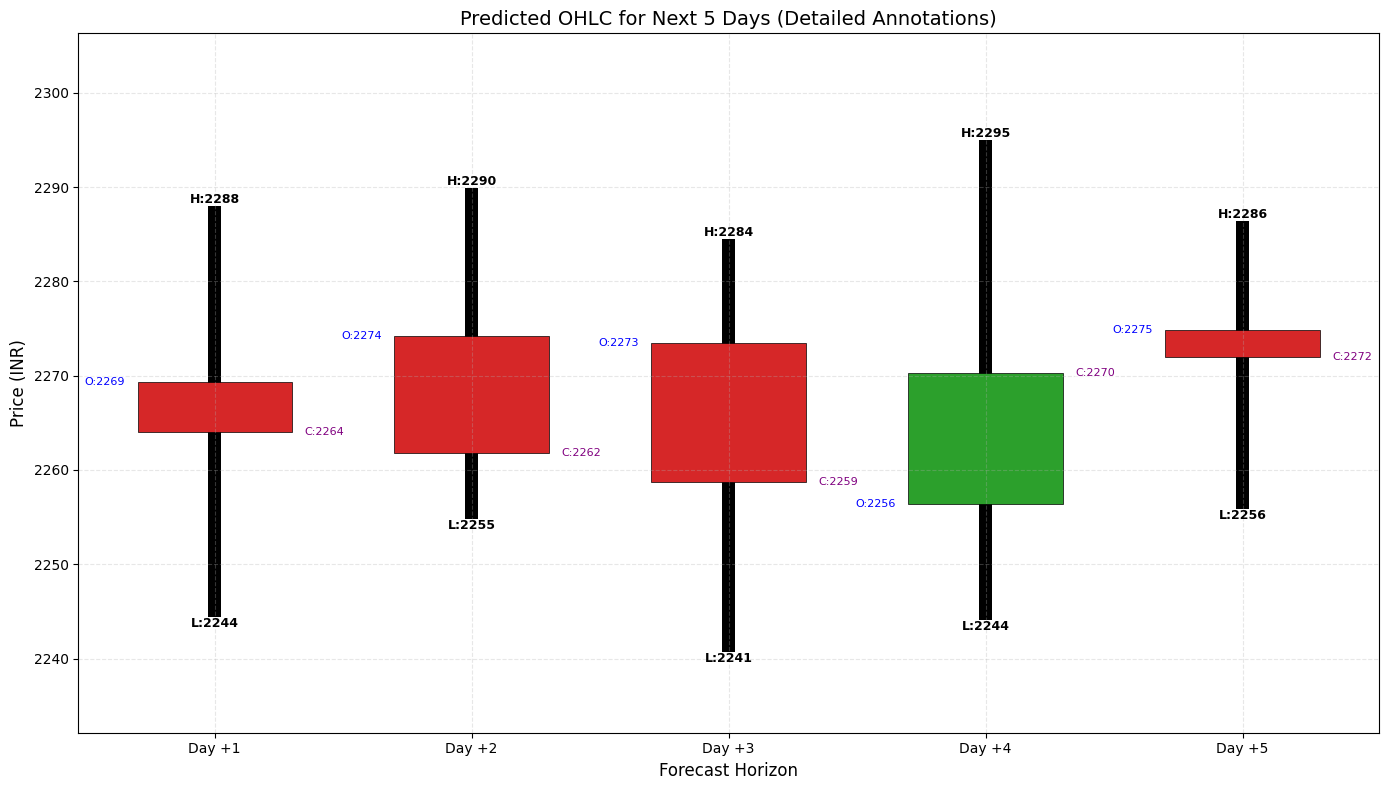

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. DATA PREP ---
# Assuming 'real_prediction' holds your final (N, 4) numpy array
# Convert to DataFrame for easier plotting logic
pred_df = pd.DataFrame(real_prediction, columns=['Open', 'High', 'Low', 'Close'])
N = len(pred_df)
ind = np.arange(N) # The x-axis indices

# --- 2. PLOT SETUP ---
fig, ax = plt.subplots(figsize=(14, 8))

# Visual settings
width = 0.6      # Width of the candle body
width2 = 0.05    # Width of the wick line
up_color = '#2ca02c'   # Matplotlib standard green
down_color = '#d62728' # Matplotlib standard red
# Label offsets/styling
o_c_offset = 0.35 # How far left/right to move Open/Close labels
lbl_font = 8
hl_font = 9

print("Generating chart with detailed annotations...")

# --- 3. MAIN LOOP: DRAW CANDLES & LABELS ---
for i, row in pred_df.iterrows():
    # Determine color and body dimensions
    if row['Close'] >= row['Open']:
        color = up_color
        body_bottom = row['Open']
        body_height = row['Close'] - row['Open']
    else:
        color = down_color
        body_bottom = row['Close']
        body_height = row['Open'] - row['Close']

    # A. Draw Wick (High to Low)
    ax.bar(i, row['High'] - row['Low'], bottom=row['Low'], width=width2, color='black')

    # B. Draw Body (Open to Close)
    ax.bar(i, body_height, bottom=body_bottom, width=width, color=color, edgecolor='black', linewidth=0.5)

    # --- C. DETAILED ANNOTATIONS ---
    # Using f"{value:.0f}" to round to whole numbers to save space
    
    # 1. High Label (Centered Above)
    ax.text(i, row['High'], f"H:{row['High']:.0f}", 
            ha='center', va='bottom', fontsize=hl_font, fontweight='bold', zorder=5)

    # 2. Low Label (Centered Below)
    ax.text(i, row['Low'], f"L:{row['Low']:.0f}", 
            ha='center', va='top', fontsize=hl_font, fontweight='bold', zorder=5)
            
    # 3. Open Label (Offset Left, Blue)
    ax.text(i - o_c_offset, row['Open'], f"O:{row['Open']:.0f}", 
            ha='right', va='center', fontsize=lbl_font, color='blue', zorder=5,
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5))

    # 4. Close Label (Offset Right, Purple)
    ax.text(i + o_c_offset, row['Close'], f"C:{row['Close']:.0f}", 
            ha='left', va='center', fontsize=lbl_font, color='purple', zorder=5,
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5))


# --- 4. FINAL FORMATTING ---
ax.set_title(f'Predicted OHLC for Next {N} Days (Detailed Annotations)', fontsize=14)
ax.set_ylabel('Price (INR)', fontsize=12)
ax.set_xlabel('Forecast Horizon', fontsize=12)

# Set x-ticks to show Day +1, Day +2, etc.
ax.set_xticks(ind)
ax.set_xticklabels([f'Day +{i+1}' for i in ind])

# Add grid
ax.grid(True, linestyle='--', alpha=0.3)

# Crucial: Manually expand Y-axis limits to make room for top/bottom labels
ymin, ymax = ax.get_ylim()
range_padding = (ymax - ymin) * 0.15 # Add 15% padding top and bottom
ax.set_ylim(ymin - range_padding, ymax + range_padding)

plt.tight_layout()
print("Chart generated successfully.")
plt.show()


Capping returns between: -0.0343 (-3.43%) and 0.0358 (3.58%)

--- Statistics After Cleanup ---
count    1238.000000
mean        0.000096
std         0.011952
min        -0.034271
25%        -0.006789
50%        -0.000296
75%         0.006624
max         0.035829
Name: Return_Clean, dtype: float64


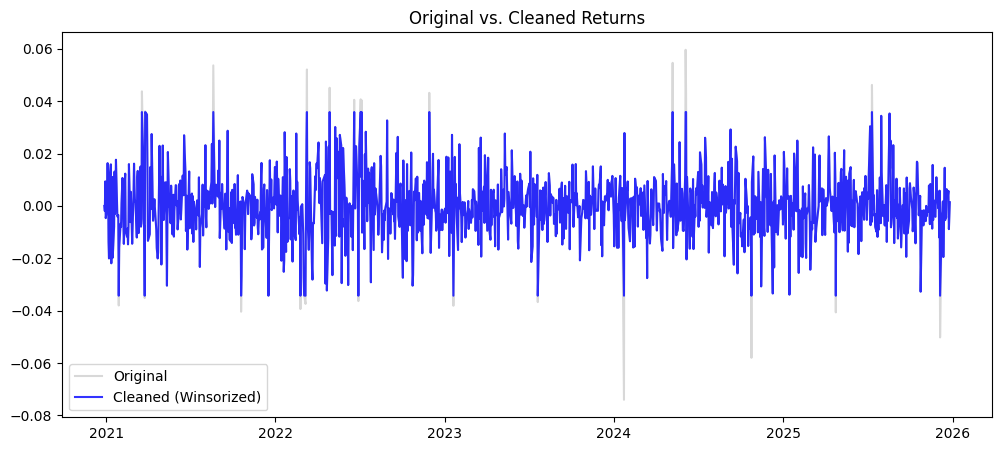

In [ ]:
import matplotlib.pyplot as plt
# --- 3. OUTLIER HANDLING (Winsorization) ---
# We cap returns at the 1st and 99th percentiles.
# This keeps the crash "events" but removes the infinite/extreme spikes that break AI models.
lower_limit = df['Return'].quantile(0.01)
upper_limit = df['Return'].quantile(0.99)

print(f"\nCapping returns between: {lower_limit:.4f} ({lower_limit*100:.2f}%) and {upper_limit:.4f} ({upper_limit*100:.2f}%)")

df['Return_Clean'] = df['Return'].clip(lower=lower_limit, upper=upper_limit)

# --- 4. MISSING VALUE HANDLING ---
# Fills the first row NaN (created by pct_change) with 0
df['Return_Clean'] = df['Return_Clean'].fillna(0)

# Verify cleanup
print("\n--- Statistics After Cleanup ---")
print(df['Return_Clean'].describe())

# Compare visually
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Return'], label='Original', alpha=0.3, color='gray')
plt.plot(df['Date'], df['Return_Clean'], label='Cleaned (Winsorized)', alpha=0.8, color='blue')
plt.title("Original vs. Cleaned Returns")
plt.legend()
plt.show()

# --- 5. UPDATE DF ---
# Set the main 'Return' column to the cleaned version
df['Return'] = df['Return_Clean']
df.drop(columns=['Return_Clean'], inplace=True)

In [10]:
import pandas as pd
import torch
import numpy as np
from chronos import ChronosPipeline

# --- 1. MODEL SETUP (Run this once) ---
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

# --- 2. DATA SETUP ---
# Assuming 'df' is your existing dataframe
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df['Return'] = df['Close'].pct_change()

def predict_for_date(target_date_str, df, model_pipeline, lookback_window=20):
    """
    Predicts the return for a specific target_date using the previous 'lookback_window' days.
    """
    target_date = pd.to_datetime(target_date_str)
    
    # 1. Get data STRICTLY BEFORE the target date
    # We want the 'Close' prices leading up to this day to calculate returns
    # We need (lookback_window + 1) rows of price data to calculate (lookback_window) returns
    past_data = df[df['Date'] < target_date].tail(lookback_window + 1).copy()
    
    # Check if we have enough data
    if len(past_data) < lookback_window + 1:
        print(f"❌ Not enough historical data before {target_date_str} to build context.")
        return

    # 2. Calculate Returns for this specific window
    # We recalculate here to ensure the window is self-contained
    past_data['Window_Return'] = past_data['Close'].pct_change()
    
    # Drop the first NaN created by pct_change inside this window
    clean_returns = past_data['Window_Return'].dropna().tolist()
    
    # Ensure we have exactly the window size (e.g., 20)
    input_returns = clean_returns[-lookback_window:]
    
    # 3. Predict using Chronos
    context_tensor = torch.tensor(input_returns).unsqueeze(0) # Shape (1, 20)
    
    forecast = model_pipeline.predict(
        context_tensor,
        prediction_length=1,
        num_samples=100
    )
    
    # 4. Extract Prediction (Median)
    predicted_return = np.median(forecast[0, :, 0].numpy())
    
    # 5. Check Actual Result (if available in df)
    actual_row = df[df['Date'] == target_date]
    actual_return_str = "N/A"
    
    print(f"\n--- FORECAST FOR: {target_date_str} ---")
    print(f"Context: {len(input_returns)} days (From {past_data.iloc[1]['Date'].date()} to {past_data.iloc[-1]['Date'].date()})")
    print(f"Model Prediction: {predicted_return:.5f} ({predicted_return*100:.2f}%)")
    
    if not actual_row.empty:
        actual_return = actual_row.iloc[0]['Return']
        error = abs(predicted_return - actual_return)
        print(f"Actual Market Move: {actual_return:.5f} ({actual_return*100:.2f}%)")
        print(f"Difference: {error:.5f}")
        
        # Simple Direction Check
        pred_dir = "GREEN" if predicted_return > 0 else "RED"
        act_dir = "GREEN" if actual_return > 0 else "RED"
        print(f"Direction Correct? {'✅ YES' if pred_dir == act_dir else '❌ NO'}")
    else:
        print("Actual data not found in DF (Future date?)")

# --- 3. RUN IT ---
# Example: Predict for Dec 20, 2025
predict_for_date("2025-12-20", df, pipeline)

# Example: Predict for Dec 24, 2025
predict_for_date("2025-12-24", df, pipeline)

ModuleNotFoundError: No module named 'chronos'